# 🐦 Bird Species Observation Analysis
**Domain:** Environmental Studies, Biodiversity Conservation, Ecology  
**Dataset:** Forest + Grassland bird monitoring data across 11 admin units  

---
## Notebook Structure
1. Setup & Data Loading
2. Phase 3 — EDA (Temporal, Spatial, Species, Environmental, Distance, Observer)
3. Phase 4 — SQL Database Loading
4. Phase 4 — Visualizations (Plotly)
5. Streamlit App Code

## ⚙️ Setup — Install & Import Libraries

In [33]:
!pip install pandas openpyxl plotly sqlalchemy

In [34]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sqlite3
import warnings
warnings.filterwarnings('ignore')

print('✓ All libraries imported successfully')

✓ All libraries imported successfully


## 📂 Phase 1 & 2 — Load Cleaned Dataset
> If you already ran the cleaning script, just load the CSV. Otherwise run the full load+clean below.

In [35]:
df = pd.read_csv('Bird_Cleaned_Dataset.csv', parse_dates=['Date'])
print(f'Loaded: {len(df):,} rows × {df.shape[1]} columns')
df.head(3)

Loaded: 15,368 rows × 32 columns


,Admin_Unit_Code,Sub_Unit_Code,Site_Name,Plot_Name,Location_Type,Year,Date,Month,Season,Start_Time,...,AOU_Code,PIF_Watchlist_Status,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Previously_Obs,Initial_Three_Min_Cnt
0,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,5,Spring,06:19,...,EATO,False,True,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,True
1,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,5,Spring,06:19,...,WBNU,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,True
2,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,5,Spring,06:19,...,RBWO,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,False


In [36]:
FOREST_PATH    = 'Bird_Monitoring_Data_FOREST.XLSX'
GRASSLAND_PATH = 'Bird_Monitoring_Data_GRASSLAND.XLSX'

def load_all_sheets(path):
    xl = pd.ExcelFile(path)
    return pd.concat([xl.parse(s) for s in xl.sheet_names], ignore_index=True)

forest_df    = load_all_sheets(FOREST_PATH)
grassland_df = load_all_sheets(GRASSLAND_PATH)

forest_df['Previously_Obs'] = np.nan
grassland_df['Site_Name']   = np.nan
grassland_df.rename(columns={'TaxonCode': 'NPSTaxonCode'}, inplace=True)

df = pd.concat([forest_df, grassland_df], ignore_index=True)

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

def time_to_str(series):
    def convert(val):
        try:
            if pd.isnull(val): return np.nan
        except: pass
        try: return val.strftime('%H:%M')
        except:
            try:
                val = float(val)
                total = round(val * 24 * 60)
                h, m = divmod(total, 60)
                return f'{h:02d}:{m:02d}'
            except: return np.nan
    return series.apply(convert)

df['Start_Time'] = time_to_str(df['Start_Time'])
df['End_Time']   = time_to_str(df['End_Time'])
df['Year']       = df['Year'].fillna(0).astype(int)
df['Month']      = df['Date'].dt.month
df['Season']     = df['Month'].map({12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',6:'Summer',7:'Summer',8:'Summer',9:'Fall',10:'Fall',11:'Fall'})
df['Sex']        = df['Sex'].fillna('Undetermined').str.strip().replace('', 'Undetermined')
df['Distance']   = df['Distance'].fillna('').str.strip()
df.loc[(df['Distance']=='') & (df['Flyover_Observed']==True), 'Distance'] = 'Flyover'
df.loc[df['Distance']=='', 'Distance'] = 'Unknown'
df['Sub_Unit_Code']  = df['Sub_Unit_Code'].fillna('NA')
df['Site_Name']      = df['Site_Name'].fillna('N/A')
df['Previously_Obs'] = df['Previously_Obs'].fillna(False)
df['Disturbance']    = df['Disturbance'].fillna('Unknown')

bool_map = {True:True,False:False,'TRUE':True,'FALSE':False,1:True,0:False}
for col in ['PIF_Watchlist_Status','Regional_Stewardship_Status','Flyover_Observed','Initial_Three_Min_Cnt','Previously_Obs']:
    df[col] = df[col].map(bool_map).fillna(False)

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
df.to_csv('Bird_Cleaned_Dataset.csv', index=False)
print(f'✓ Cleaned: {len(df):,} rows × {df.shape[1]} columns')

✓ Cleaned: 15,368 rows × 32 columns


---
## 📊 Phase 3 — Exploratory Data Analysis
### 3.1 Dataset Overview

In [37]:
print('=== DATASET OVERVIEW ===')
print(f'Total observations : {len(df):,}')
print(f'Unique species     : {df["Scientific_Name"].nunique()}')
print(f'Unique plots       : {df["Plot_Name"].nunique()}')
print(f'Admin units        : {sorted(df["Admin_Unit_Code"].unique())}')
print(f'Date range         : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Location types     : {df["Location_Type"].value_counts().to_dict()}')
print(f'Watchlist species  : {df[df["PIF_Watchlist_Status"]==True]["Scientific_Name"].nunique()}')
print()
print('--- Null Summary ---')
nulls = df.isnull().sum()
print(nulls[nulls > 0])

=== DATASET OVERVIEW ===
Total observations : 15,368
Unique species     : 127
Unique plots       : 609
Admin units        : ['ANTI', 'CATO', 'CHOH', 'GWMP', 'HAFE', 'MANA', 'MONO', 'NACE', 'PRWI', 'ROCR', 'WOTR']
Date range         : 2018-05-07 → 2018-07-19
Location types     : {'Forest': 8542, 'Grassland': 6826}
Watchlist species  : 8

--- Null Summary ---
ID_Method        2
AcceptedTSN     28
NPSTaxonCode     2
dtype: int64


### 3.2 Temporal Analysis

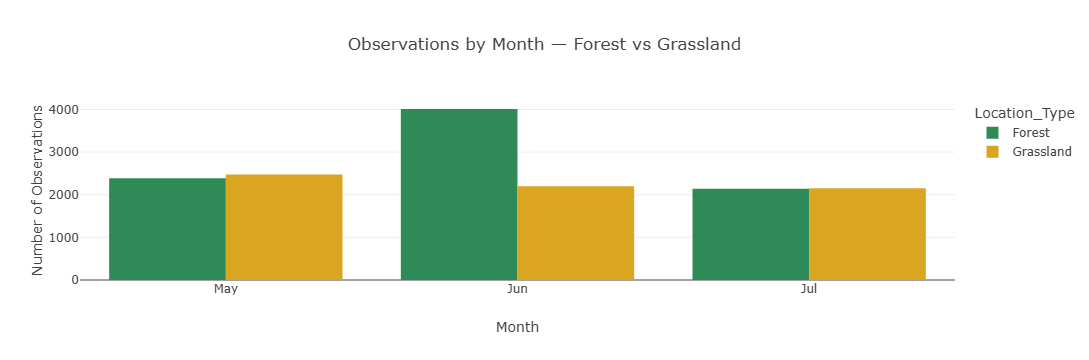

In [38]:
monthly = df.groupby(['Month','Location_Type']).size().reset_index(name='Count')
month_names = {5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec',1:'Jan',2:'Feb',3:'Mar',4:'Apr'}
monthly['Month_Name'] = monthly['Month'].map(month_names)

fig = px.bar(monthly, x='Month_Name', y='Count', color='Location_Type',
             barmode='group', title='Observations by Month — Forest vs Grassland',
             color_discrete_map={'Forest':'#2E8B57','Grassland':'#DAA520'},
             labels={'Month_Name':'Month','Count':'Number of Observations'})
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

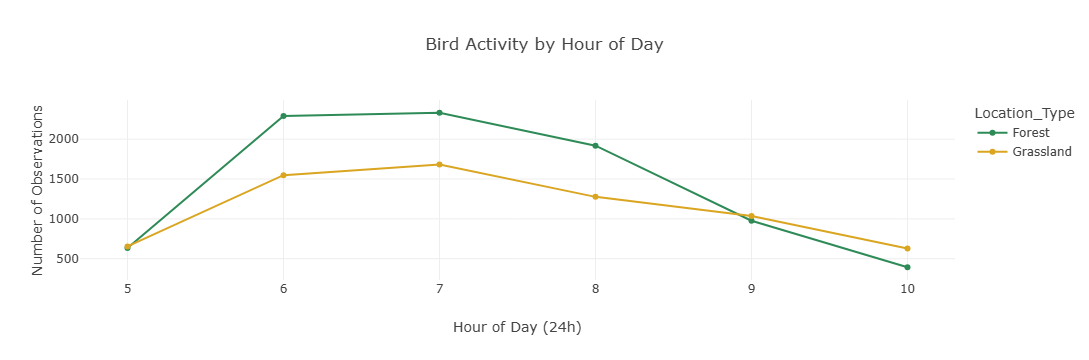

In [39]:
df['Hour'] = df['Start_Time'].str.split(':').str[0].astype(float)
hourly = df.groupby(['Hour','Location_Type']).size().reset_index(name='Count')
hourly = hourly.dropna(subset=['Hour'])

fig = px.line(hourly, x='Hour', y='Count', color='Location_Type',
              title='Bird Activity by Hour of Day',
              color_discrete_map={'Forest':'#2E8B57','Grassland':'#DAA520'},
              labels={'Hour':'Hour of Day (24h)','Count':'Number of Observations'})
fig.update_traces(mode='lines+markers')
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

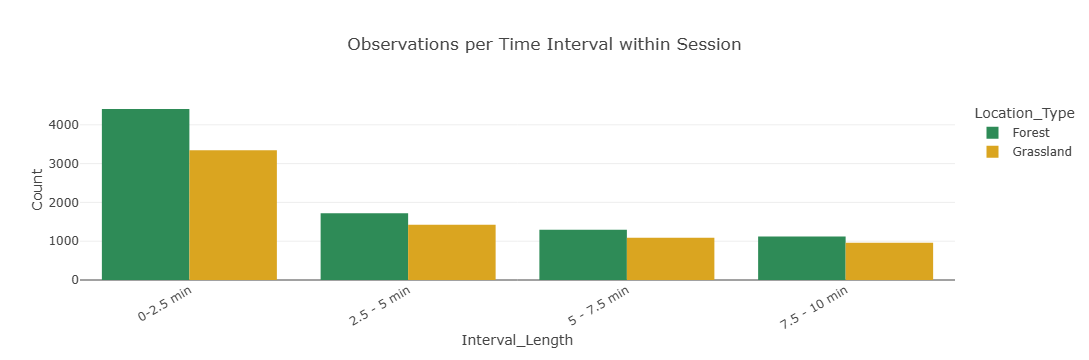

In [40]:
interval_counts = df.groupby(['Interval_Length','Location_Type']).size().reset_index(name='Count')

fig = px.bar(interval_counts, x='Interval_Length', y='Count', color='Location_Type',
             barmode='group', title='Observations per Time Interval within Session',
             color_discrete_map={'Forest':'#2E8B57','Grassland':'#DAA520'})
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white', xaxis_tickangle=-30)
fig.show()

### 3.3 Spatial Analysis

  Location_Type  Total_Observations  Unique_Species  Unique_Plots
0        Forest                8542             108           408
1     Grassland                6826             107           201


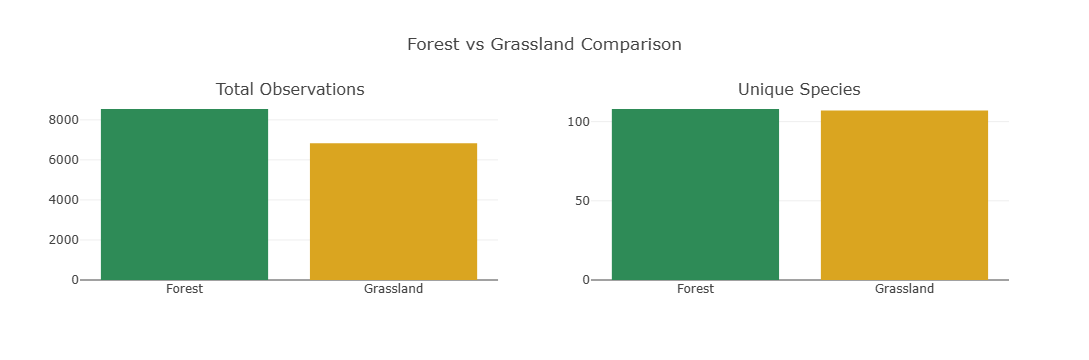

In [41]:
spatial_summary = df.groupby('Location_Type').agg(
    Total_Observations=('Common_Name','count'),
    Unique_Species=('Scientific_Name','nunique'),
    Unique_Plots=('Plot_Name','nunique')
).reset_index()
print(spatial_summary)

fig = make_subplots(rows=1, cols=2, subplot_titles=['Total Observations','Unique Species'])
colors = ['#2E8B57','#DAA520']
fig.add_trace(go.Bar(x=spatial_summary['Location_Type'], y=spatial_summary['Total_Observations'],
                     marker_color=colors, showlegend=False), row=1, col=1)
fig.add_trace(go.Bar(x=spatial_summary['Location_Type'], y=spatial_summary['Unique_Species'],
                     marker_color=colors, showlegend=False), row=1, col=2)
fig.update_layout(title='Forest vs Grassland Comparison', plot_bgcolor='white', paper_bgcolor='white')
fig.show()

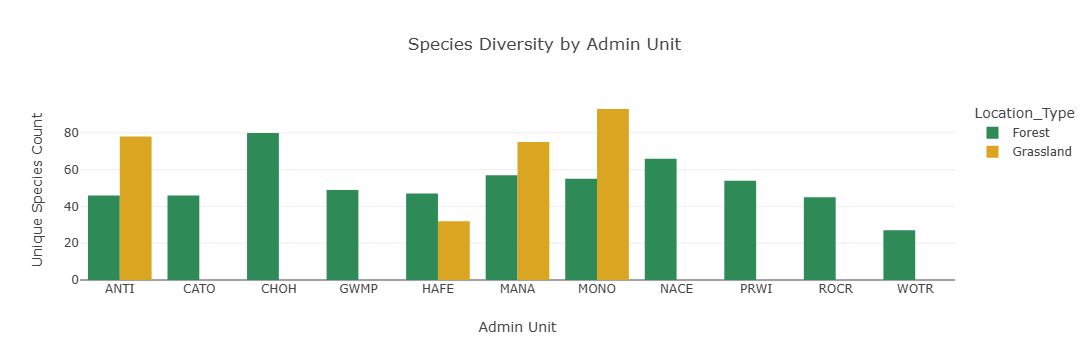

In [42]:
admin_diversity = df.groupby(['Admin_Unit_Code','Location_Type']).agg(
    Unique_Species=('Scientific_Name','nunique'),
    Total_Obs=('Common_Name','count')
).reset_index()

fig = px.bar(admin_diversity, x='Admin_Unit_Code', y='Unique_Species', color='Location_Type',
             barmode='group', title='Species Diversity by Admin Unit',
             color_discrete_map={'Forest':'#2E8B57','Grassland':'#DAA520'},
             labels={'Admin_Unit_Code':'Admin Unit','Unique_Species':'Unique Species Count'})
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

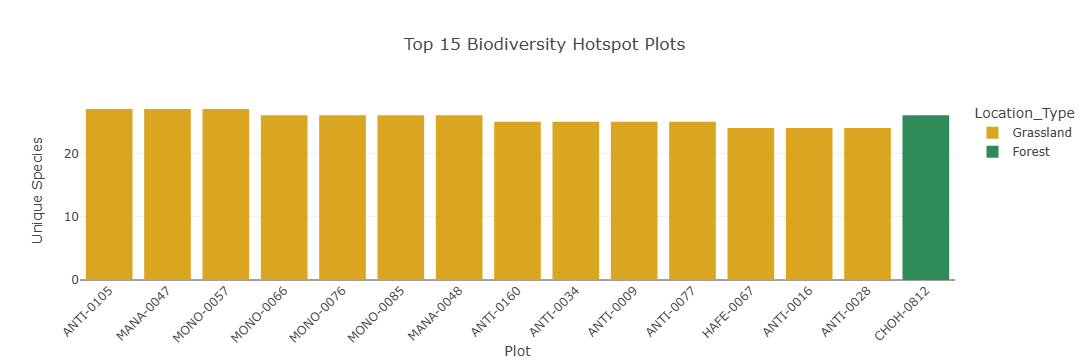

In [43]:
plot_hotspots = df.groupby(['Plot_Name','Location_Type']).agg(
    Unique_Species=('Scientific_Name','nunique'),
    Total_Obs=('Common_Name','count')
).reset_index().sort_values('Unique_Species', ascending=False).head(15)

fig = px.bar(plot_hotspots, x='Plot_Name', y='Unique_Species', color='Location_Type',
             title='Top 15 Biodiversity Hotspot Plots',
             color_discrete_map={'Forest':'#2E8B57','Grassland':'#DAA520'},
             labels={'Plot_Name':'Plot','Unique_Species':'Unique Species'})
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white', xaxis_tickangle=-45)
fig.show()

### 3.4 Species Analysis

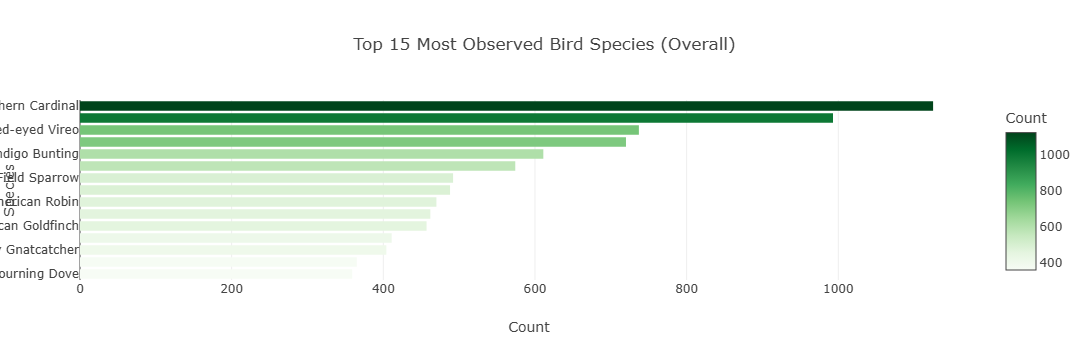

In [47]:
top_species = df['Common_Name'].value_counts().head(15).reset_index()
top_species.columns = ['Species','Count']

fig = px.bar(top_species, x='Count', y='Species', orientation='h',
             title='Top 15 Most Observed Bird Species (Overall)',
             color='Count', color_continuous_scale='Greens')
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white', yaxis={'categoryorder':'total ascending'})
fig.show()

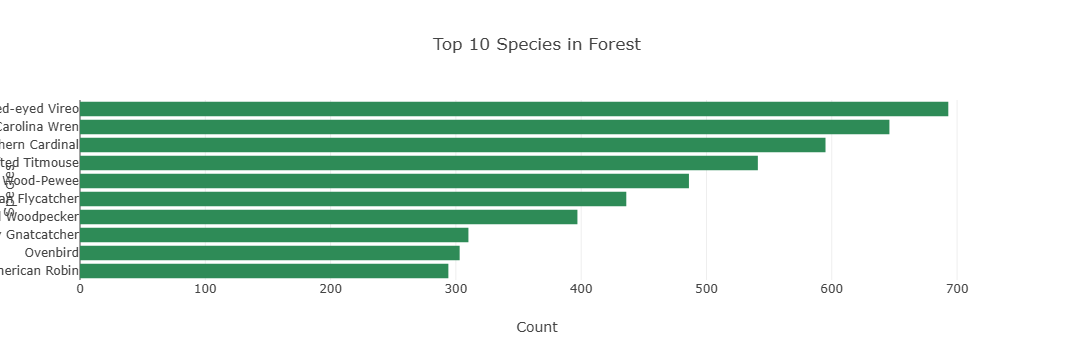

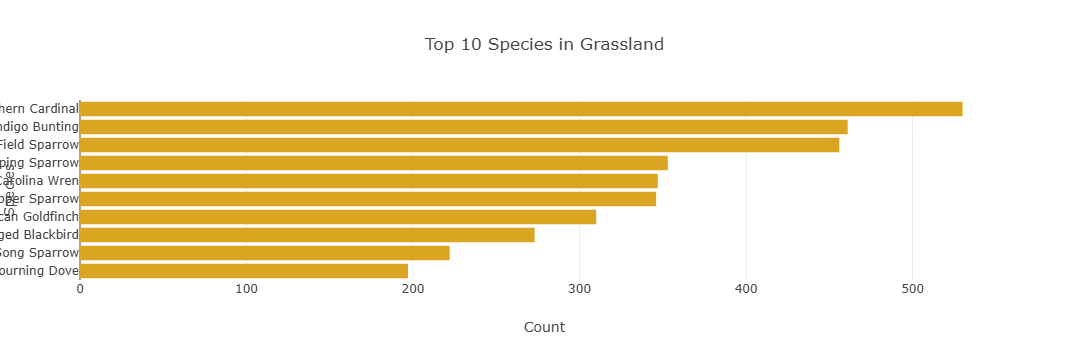

In [45]:
for habitat in ['Forest','Grassland']:
    top = df[df['Location_Type']==habitat]['Common_Name'].value_counts().head(10).reset_index()
    top.columns = ['Species','Count']
    fig = px.bar(top, x='Count', y='Species', orientation='h',
                 title=f'Top 10 Species in {habitat}',
                 color_discrete_sequence=['#2E8B57'] if habitat=='Forest' else ['#DAA520'])
    fig.update_layout(plot_bgcolor='white', paper_bgcolor='white', yaxis={'categoryorder':'total ascending'})
    fig.show()

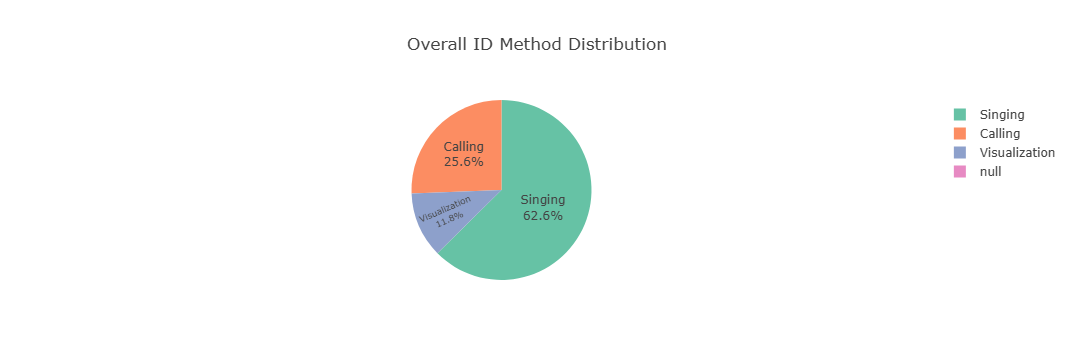

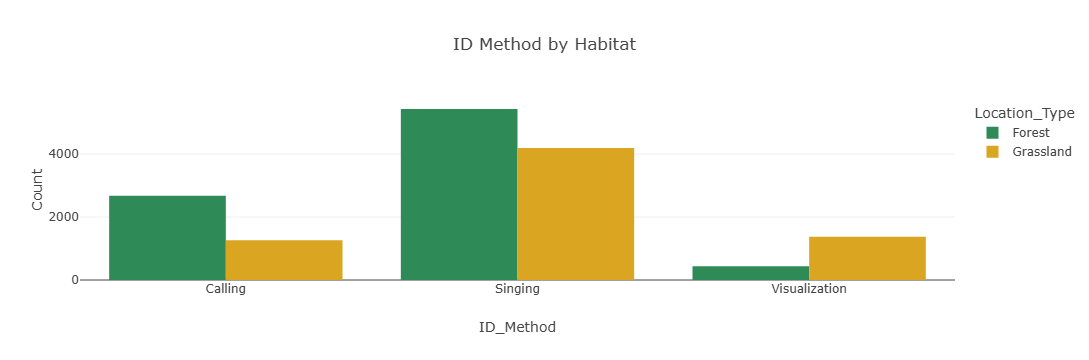

In [48]:
id_method = df.groupby(['ID_Method','Location_Type']).size().reset_index(name='Count')

fig = px.pie(df, names='ID_Method', title='Overall ID Method Distribution',
             color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

fig2 = px.bar(id_method, x='ID_Method', y='Count', color='Location_Type', barmode='group',
              title='ID Method by Habitat',
              color_discrete_map={'Forest':'#2E8B57','Grassland':'#DAA520'})
fig2.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig2.show()

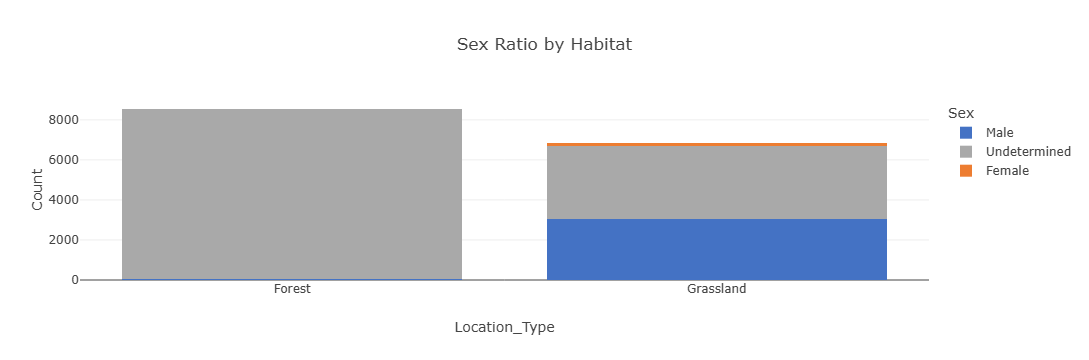

In [49]:
sex_ratio = df.groupby(['Location_Type','Sex']).size().reset_index(name='Count')

fig = px.bar(sex_ratio, x='Location_Type', y='Count', color='Sex', barmode='stack',
             title='Sex Ratio by Habitat',
             color_discrete_map={'Male':'#4472C4','Female':'#ED7D31','Undetermined':'#A9A9A9'})
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()


=== WATCHLIST SPECIES (8 total) ===
          Common_Name  Observations          Habitats
          Wood Thrush           309 Forest, Grassland
  Worm-eating Warbler            31            Forest
      Prairie Warbler            25 Forest, Grassland
     Cerulean Warbler             7            Forest
    Willow Flycatcher             2         Grassland
     Kentucky Warbler             2 Forest, Grassland
  Blue-winged Warbler             1            Forest
Red-headed Woodpecker             1            Forest


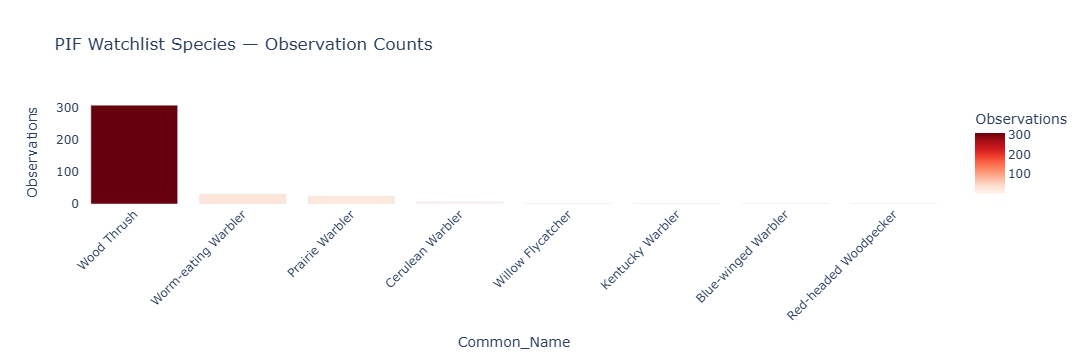

In [16]:
# Conservation watchlist species
watchlist = df[df['PIF_Watchlist_Status']==True].groupby('Common_Name').agg(
    Observations=('Common_Name','count'),
    Habitats=('Location_Type', lambda x: ', '.join(sorted(x.unique())))
).reset_index().sort_values('Observations', ascending=False)

print(f'\n=== WATCHLIST SPECIES ({len(watchlist)} total) ===')
print(watchlist.to_string(index=False))

fig = px.bar(watchlist.head(15), x='Common_Name', y='Observations',
             title='PIF Watchlist Species — Observation Counts',
             color='Observations', color_continuous_scale='Reds')
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white', xaxis_tickangle=-45)
fig.show()

### 3.5 Environmental Conditions Analysis

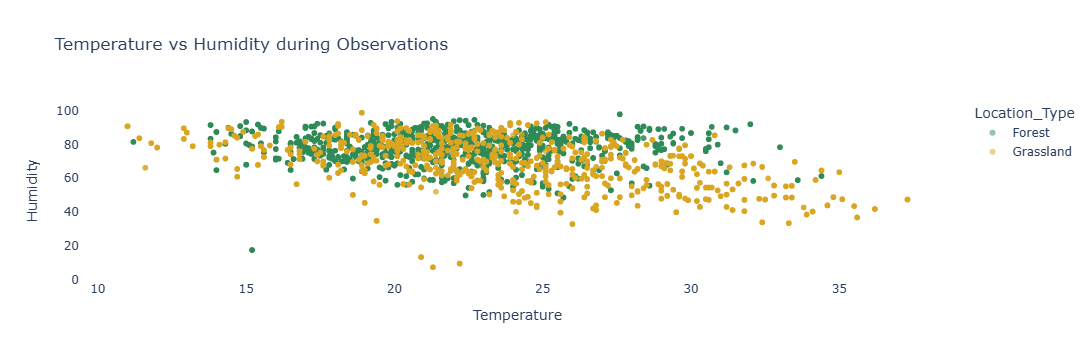

In [17]:
# Temperature vs observation count
temp_bins = df.copy()
temp_bins['Temp_Bin'] = pd.cut(temp_bins['Temperature'], bins=10)
temp_obs = temp_bins.groupby(['Temp_Bin','Location_Type']).size().reset_index(name='Count')
temp_obs['Temp_Bin'] = temp_obs['Temp_Bin'].astype(str)

fig = px.scatter(df.dropna(subset=['Temperature']), x='Temperature', y='Humidity',
                 color='Location_Type', size_max=8,
                 title='Temperature vs Humidity during Observations',
                 color_discrete_map={'Forest':'#2E8B57','Grassland':'#DAA520'},
                 opacity=0.5)
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

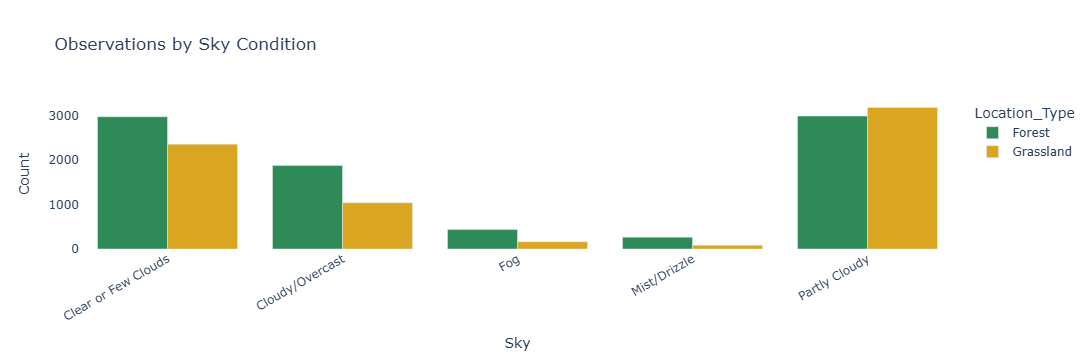

In [18]:
# Sky condition vs observation count
sky_counts = df.groupby(['Sky','Location_Type']).size().reset_index(name='Count')

fig = px.bar(sky_counts, x='Sky', y='Count', color='Location_Type', barmode='group',
             title='Observations by Sky Condition',
             color_discrete_map={'Forest':'#2E8B57','Grassland':'#DAA520'})
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white', xaxis_tickangle=-30)
fig.show()

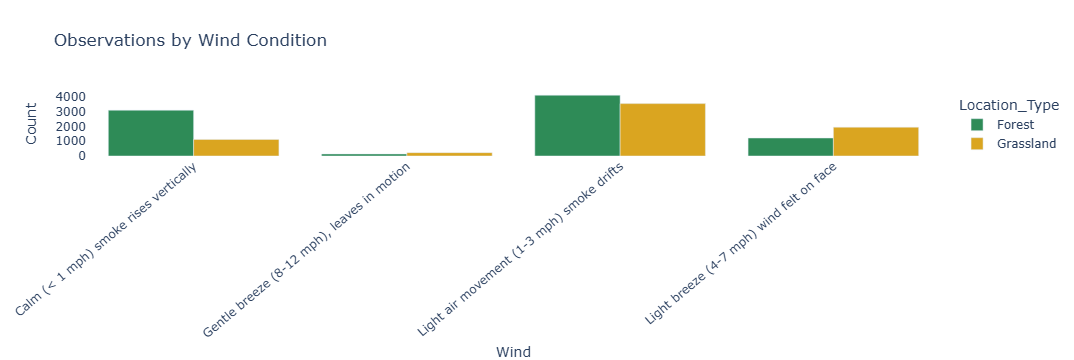

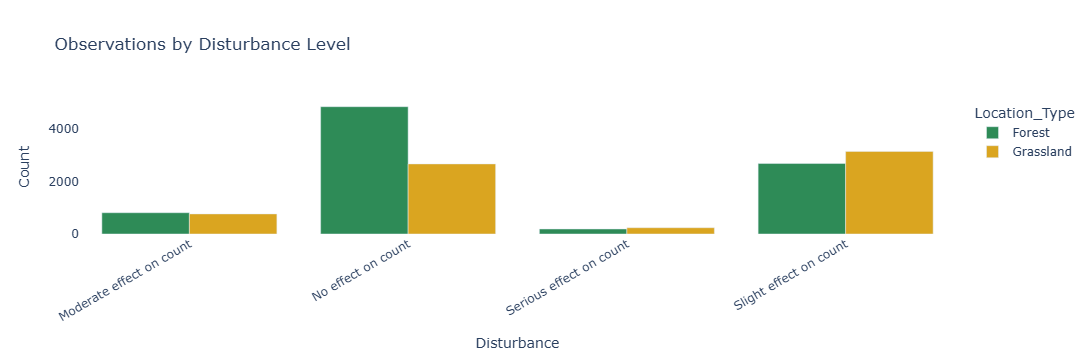

In [19]:
# Wind condition vs observation count
wind_counts = df.groupby(['Wind','Location_Type']).size().reset_index(name='Count')

fig = px.bar(wind_counts, x='Wind', y='Count', color='Location_Type', barmode='group',
             title='Observations by Wind Condition',
             color_discrete_map={'Forest':'#2E8B57','Grassland':'#DAA520'})
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white', xaxis_tickangle=-40)
fig.show()

# Disturbance effect
dist_counts = df.groupby(['Disturbance','Location_Type']).size().reset_index(name='Count')
fig2 = px.bar(dist_counts, x='Disturbance', y='Count', color='Location_Type', barmode='group',
              title='Observations by Disturbance Level',
              color_discrete_map={'Forest':'#2E8B57','Grassland':'#DAA520'})
fig2.update_layout(plot_bgcolor='white', paper_bgcolor='white', xaxis_tickangle=-30)
fig2.show()

### 3.6 Distance & Behavior Analysis

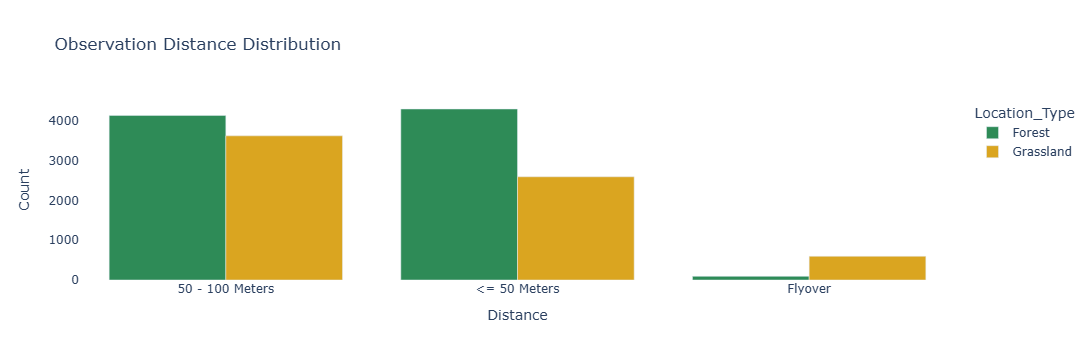

In [20]:
# Distance distribution
dist_dist = df.groupby(['Distance','Location_Type']).size().reset_index(name='Count')

fig = px.bar(dist_dist, x='Distance', y='Count', color='Location_Type', barmode='group',
             title='Observation Distance Distribution',
             color_discrete_map={'Forest':'#2E8B57','Grassland':'#DAA520'})
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

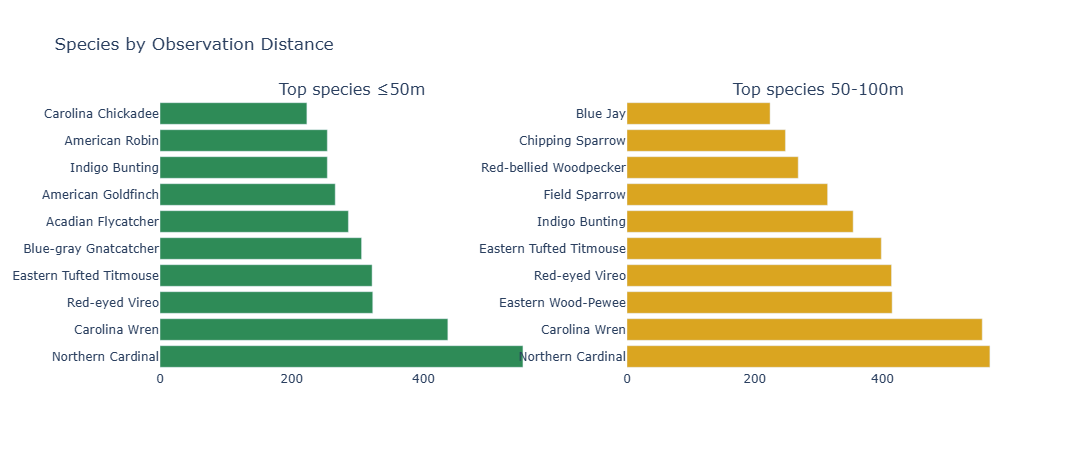

In [21]:
# Top species seen close (<=50m) vs far (50-100m)
close = df[df['Distance']=='<= 50 Meters']['Common_Name'].value_counts().head(10)
far   = df[df['Distance']=='50 - 100 Meters']['Common_Name'].value_counts().head(10)

fig = make_subplots(rows=1, cols=2, subplot_titles=['Top species ≤50m','Top species 50-100m'])
fig.add_trace(go.Bar(x=close.values, y=close.index, orientation='h', marker_color='#2E8B57', showlegend=False), row=1, col=1)
fig.add_trace(go.Bar(x=far.values,   y=far.index,   orientation='h', marker_color='#DAA520', showlegend=False), row=1, col=2)
fig.update_layout(title='Species by Observation Distance', plot_bgcolor='white', paper_bgcolor='white', height=450)
fig.show()

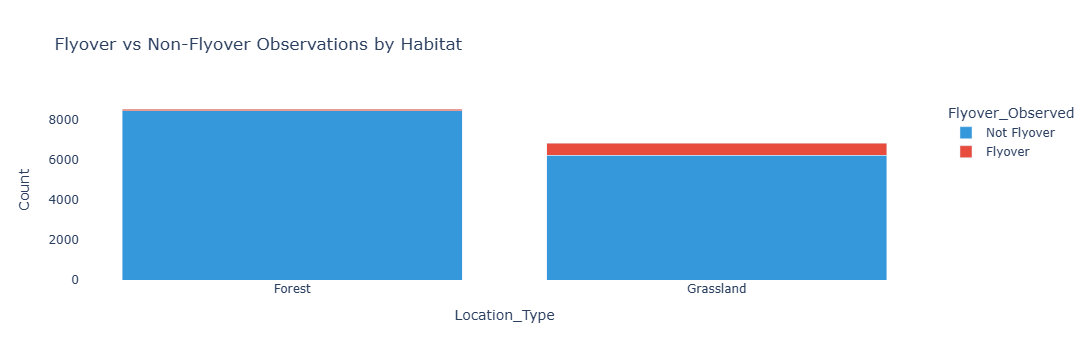

In [22]:
# Flyover frequency
flyover = df.groupby(['Location_Type','Flyover_Observed']).size().reset_index(name='Count')
flyover['Flyover_Observed'] = flyover['Flyover_Observed'].map({True:'Flyover',False:'Not Flyover'})

fig = px.bar(flyover, x='Location_Type', y='Count', color='Flyover_Observed', barmode='stack',
             title='Flyover vs Non-Flyover Observations by Habitat',
             color_discrete_map={'Flyover':'#E74C3C','Not Flyover':'#3498DB'})
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

### 3.7 Observer Analysis

        Observer  Total_Obs  Unique_Species  Plots_Visited
Elizabeth Oswald       5759             120            489
  Kimberly Serno       5346              91            456
  Brian Swimelar       4263              84            461


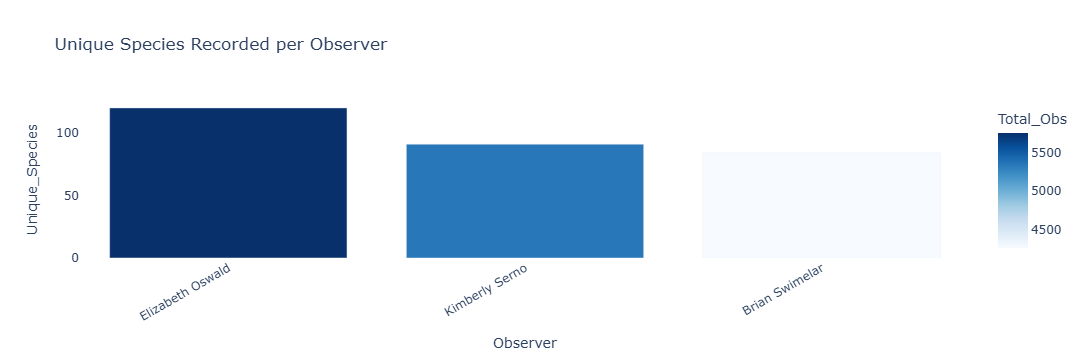

In [23]:
# Observer productivity
observer_stats = df.groupby('Observer').agg(
    Total_Obs=('Common_Name','count'),
    Unique_Species=('Scientific_Name','nunique'),
    Plots_Visited=('Plot_Name','nunique')
).reset_index().sort_values('Total_Obs', ascending=False)

print(observer_stats.to_string(index=False))

fig = px.bar(observer_stats, x='Observer', y='Unique_Species',
             title='Unique Species Recorded per Observer',
             color='Total_Obs', color_continuous_scale='Blues')
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white', xaxis_tickangle=-30)
fig.show()

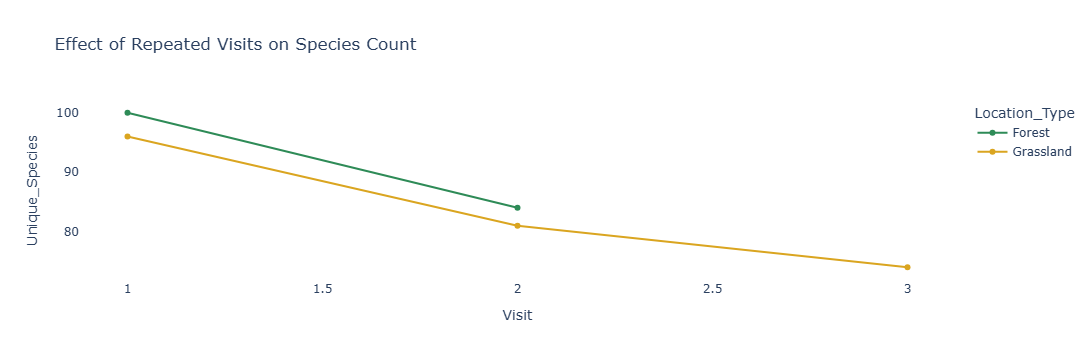

In [24]:
# Visit effect: does revisiting a plot increase species count?
visit_effect = df.groupby(['Visit','Location_Type']).agg(
    Unique_Species=('Scientific_Name','nunique'),
    Total_Obs=('Common_Name','count')
).reset_index()

fig = px.line(visit_effect, x='Visit', y='Unique_Species', color='Location_Type',
              title='Effect of Repeated Visits on Species Count',
              color_discrete_map={'Forest':'#2E8B57','Grassland':'#DAA520'},
              markers=True)
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

---
## 🗄️ Phase 4 — SQL Database Loading
Store the cleaned dataset in SQLite so you can query it for visualizations.

In [25]:
import sqlite3

DB_PATH = 'bird_observations.db'
conn = sqlite3.connect(DB_PATH)

# Load full cleaned dataset into SQL
df.to_sql('observations', conn, if_exists='replace', index=False)
print(f'✓ Loaded {len(df):,} rows into SQLite → table: observations')

# Verify
result = pd.read_sql('SELECT COUNT(*) as total FROM observations', conn)
print(result)

✓ Loaded 15,368 rows into SQLite → table: observations
   total
0  15368


In [26]:
# Example SQL Queries

# Q1: Top 10 species by observation count
q1 = pd.read_sql('''
    SELECT Common_Name, COUNT(*) as Observations
    FROM observations
    GROUP BY Common_Name
    ORDER BY Observations DESC
    LIMIT 10
''', conn)
print('Top 10 species:')
print(q1.to_string(index=False))

Top 10 species:
            Common_Name  Observations
      Northern Cardinal          1125
          Carolina Wren           993
         Red-eyed Vireo           737
Eastern Tufted Titmouse           720
         Indigo Bunting           611
     Eastern Wood-Pewee           574
          Field Sparrow           492
 Red-bellied Woodpecker           488
         American Robin           470
     Acadian Flycatcher           462


In [27]:
# Q2: Species diversity by habitat
q2 = pd.read_sql('''
    SELECT Location_Type,
           COUNT(*) as Total_Observations,
           COUNT(DISTINCT Scientific_Name) as Unique_Species
    FROM observations
    GROUP BY Location_Type
''', conn)
print('\nHabitat comparison:')
print(q2.to_string(index=False))


Habitat comparison:
Location_Type  Total_Observations  Unique_Species
       Forest                8542             108
    Grassland                6826             107


In [28]:
# Q3: Watchlist species with their habitats
q3 = pd.read_sql('''
    SELECT Common_Name, Scientific_Name,
           GROUP_CONCAT(DISTINCT Location_Type) as Found_In,
           COUNT(*) as Observations
    FROM observations
    WHERE PIF_Watchlist_Status = 1
    GROUP BY Scientific_Name
    ORDER BY Observations DESC
''', conn)
print('\nWatchlist species:')
print(q3.to_string(index=False))


Watchlist species:
          Common_Name            Scientific_Name         Found_In  Observations
          Wood Thrush       Hylocichla mustelina Forest,Grassland           309
  Worm-eating Warbler     Helmitheros vermivorus           Forest            31
      Prairie Warbler         Setophaga discolor Forest,Grassland            25
     Cerulean Warbler          Setophaga cerulea           Forest             7
     Kentucky Warbler         Oporornis formosus Forest,Grassland             2
    Willow Flycatcher         Empidonax traillii        Grassland             2
  Blue-winged Warbler       Vermivora cyanoptera           Forest             1
Red-headed Woodpecker Melanerpes erythrocephalus           Forest             1


In [29]:
# Q4: Top biodiversity hotspots
q4 = pd.read_sql('''
    SELECT Admin_Unit_Code, Plot_Name, Location_Type,
           COUNT(DISTINCT Scientific_Name) as Unique_Species,
           COUNT(*) as Total_Obs
    FROM observations
    GROUP BY Plot_Name
    ORDER BY Unique_Species DESC
    LIMIT 10
''', conn)
print('\nTop 10 hotspot plots:')
print(q4.to_string(index=False))

conn.close()
print(f'\n✓ Database saved: {DB_PATH}')


Top 10 hotspot plots:
Admin_Unit_Code Plot_Name Location_Type  Unique_Species  Total_Obs
           MONO MONO-0057     Grassland              27         48
           MANA MANA-0047     Grassland              27         46
           ANTI ANTI-0105     Grassland              27         47
           MONO MONO-0085     Grassland              26         40
           MONO MONO-0076     Grassland              26         43
           MONO MONO-0066     Grassland              26         45
           MANA MANA-0048     Grassland              26         50
           CHOH CHOH-0812        Forest              26         42
           ANTI ANTI-0160     Grassland              25         44
           ANTI ANTI-0077     Grassland              25         46

✓ Database saved: bird_observations.db


---
## 🌐 Phase 4 — Streamlit App
Run the cell below to **save the Streamlit app** as `app.py`, then launch it with:
```
streamlit run app.py
```

In [32]:
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

st.set_page_config(page_title='Bird Species Analysis', layout='wide')
st.title('Bird Species Observation Analysis')
st.markdown('**Forest & Grassland Monitoring — 11 Admin Units | 2018**')

@st.cache_data
def load_data():
    df = pd.read_csv('Bird_Cleaned_Dataset.csv', parse_dates=['Date'])
    return df

df = load_data()

# ── Sidebar Filters ──
st.sidebar.header('Filters')
habitat     = st.sidebar.multiselect('Habitat', df['Location_Type'].unique(), default=list(df['Location_Type'].unique()))
admin_units = st.sidebar.multiselect('Admin Unit', sorted(df['Admin_Unit_Code'].unique()), default=list(df['Admin_Unit_Code'].unique()))
watchlist   = st.sidebar.checkbox('Watchlist species only', value=False)

fdf = df[df['Location_Type'].isin(habitat) & df['Admin_Unit_Code'].isin(admin_units)]
if watchlist:
    fdf = fdf[fdf['PIF_Watchlist_Status'] == True]

# ── KPI Metrics ──
col1, col2, col3, col4 = st.columns(4)
col1.metric('Total Observations', f"{len(fdf):,}")
col2.metric('Unique Species',     fdf['Scientific_Name'].nunique())
col3.metric('Admin Units',        fdf['Admin_Unit_Code'].nunique())
col4.metric('Watchlist Species',  fdf[fdf['PIF_Watchlist_Status']==True]['Scientific_Name'].nunique())

st.markdown('---')
tab1, tab2, tab3, tab4, tab5 = st.tabs(['Temporal','Spatial','Species','Environment','Distance'])

# Tab 1: Temporal
with tab1:
    st.subheader('Observations by Month')
    monthly = fdf.groupby(['Month','Location_Type']).size().reset_index(name='Count')
    fig = px.bar(monthly, x='Month', y='Count', color='Location_Type', barmode='group',
                 color_discrete_map={"Forest":"#2E8B57","Grassland":"#DAA520"})
    st.plotly_chart(fig, use_container_width=True)

    st.subheader('Activity by Hour of Day')
    fdf2 = fdf.copy()
    fdf2['Hour'] = fdf2['Start_Time'].str.split(':').str[0].astype(float)
    hourly = fdf2.groupby(['Hour','Location_Type']).size().reset_index(name='Count').dropna()
    fig2 = px.line(hourly, x='Hour', y='Count', color='Location_Type', markers=True,
                   color_discrete_map={"Forest":"#2E8B57","Grassland":"#DAA520"})
    st.plotly_chart(fig2, use_container_width=True)

# Tab 2: Spatial
with tab2:
    st.subheader('Species Diversity by Admin Unit')
    admin_div = fdf.groupby(['Admin_Unit_Code','Location_Type'])['Scientific_Name'].nunique().reset_index(name='Unique_Species')
    fig = px.bar(admin_div, x='Admin_Unit_Code', y='Unique_Species', color='Location_Type', barmode='group',
                 color_discrete_map={"Forest":"#2E8B57","Grassland":"#DAA520"})
    st.plotly_chart(fig, use_container_width=True)

    st.subheader('Top 15 Hotspot Plots')
    hotspots = fdf.groupby(['Plot_Name','Location_Type'])['Scientific_Name'].nunique().reset_index(name='Unique_Species')
    hotspots = hotspots.sort_values('Unique_Species', ascending=False).head(15)
    fig2 = px.bar(hotspots, x='Plot_Name', y='Unique_Species', color='Location_Type',
                  color_discrete_map={"Forest":"#2E8B57","Grassland":"#DAA520"})
    fig2.update_layout(xaxis_tickangle=-45)
    st.plotly_chart(fig2, use_container_width=True)

# Tab 3: Species
with tab3:
    col1, col2 = st.columns(2)
    with col1:
        st.subheader('Top Species — Forest')
        top_f = fdf[fdf['Location_Type']=="Forest"]['Common_Name'].value_counts().head(10).reset_index()
        top_f.columns = ['Species','Count']
        fig = px.bar(top_f, x='Count', y='Species', orientation='h', color_discrete_sequence=['#2E8B57'])
        fig.update_layout(yaxis={'categoryorder':'total ascending'})
        st.plotly_chart(fig, use_container_width=True)
    with col2:
        st.subheader('Top Species — Grassland')
        top_g = fdf[fdf['Location_Type']=="Grassland"]['Common_Name'].value_counts().head(10).reset_index()
        top_g.columns = ['Species','Count']
        fig2 = px.bar(top_g, x='Count', y='Species', orientation='h', color_discrete_sequence=['#DAA520'])
        fig2.update_layout(yaxis={'categoryorder':'total ascending'})
        st.plotly_chart(fig2, use_container_width=True)

    st.subheader('ID Method Distribution')
    fig3 = px.pie(fdf, names='ID_Method', color_discrete_sequence=px.colors.qualitative.Set2)
    st.plotly_chart(fig3, use_container_width=True)

    st.subheader('Watchlist Species')
    wl = fdf[fdf['PIF_Watchlist_Status']==True].groupby('Common_Name').size().reset_index(name='Count').sort_values('Count',ascending=False)
    fig4 = px.bar(wl, x='Common_Name', y='Count', color='Count', color_continuous_scale='Reds')
    fig4.update_layout(xaxis_tickangle=-45)
    st.plotly_chart(fig4, use_container_width=True)

# Tab 4: Environment
with tab4:
    st.subheader('Temperature vs Humidity')
    fig = px.scatter(fdf.dropna(subset=['Temperature']), x='Temperature', y='Humidity',
                     color='Location_Type', opacity=0.5,
                     color_discrete_map={"Forest":"#2E8B57","Grassland":"#DAA520"})
    st.plotly_chart(fig, use_container_width=True)

    col1, col2 = st.columns(2)
    with col1:
        st.subheader('Sky Condition')
        sky = fdf.groupby('Sky').size().reset_index(name='Count')
        fig2 = px.bar(sky, x='Sky', y='Count', color_discrete_sequence=['#5B9BD5'])
        fig2.update_layout(xaxis_tickangle=-30)
        st.plotly_chart(fig2, use_container_width=True)
    with col2:
        st.subheader('Disturbance Effect')
        dist = fdf.groupby('Disturbance').size().reset_index(name='Count')
        fig3 = px.bar(dist, x='Disturbance', y='Count', color_discrete_sequence=['#ED7D31'])
        fig3.update_layout(xaxis_tickangle=-30)
        st.plotly_chart(fig3, use_container_width=True)

# Tab 5: Distance
with tab5:
    st.subheader('Distance Distribution')
    dist_df = fdf.groupby(['Distance','Location_Type']).size().reset_index(name='Count')
    fig = px.bar(dist_df, x='Distance', y='Count', color='Location_Type', barmode='group',
                 color_discrete_map={"Forest":"#2E8B57","Grassland":"#DAA520"})
    st.plotly_chart(fig, use_container_width=True)

    st.subheader('Flyover vs Non-Flyover')
    fly = fdf.copy()
    fly['Flyover'] = fly['Flyover_Observed'].map({True:'Flyover',False:'Not Flyover'})
    fly_cnt = fly.groupby(['Location_Type','Flyover']).size().reset_index(name='Count')
    fig2 = px.bar(fly_cnt, x='Location_Type', y='Count', color='Flyover', barmode='stack',
                  color_discrete_map={'Flyover':'#E74C3C','Not Flyover':'#3498DB'})
    st.plotly_chart(fig2, use_container_width=True)

st.markdown('---')
st.caption('Bird Species Observation Analysis | Data: NCRN Bird Monitoring 2018')

2026-05-05 02:11:45.480 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 02:11:45.482 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 02:11:45.627 
  command:

    streamlit run C:\Users\kalpana\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-05 02:11:45.631 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 02:11:45.632 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 02:11:45.634 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 02:11:45.637 Thread 'MainThread': missing ScriptRunContext! This 

DeltaGenerator()

---
## ✅ Project Completion Checklist
- [x] **Phase 1** — Data loaded from both Excel files (22 sheets total)
- [x] **Phase 2** — Data cleaned: dates, times, nulls, duplicates, booleans
- [x] **Phase 3** — EDA: Temporal, Spatial, Species, Environmental, Distance, Observer
- [x] **Phase 4** — SQL: cleaned data stored in SQLite with example queries
- [x] **Phase 4** — Visualizations: Plotly charts for all analyses
- [x] **Phase 4** — Streamlit app with filters, tabs, and interactive charts
- [ ] **Phase 5** — Write final report documenting findings and insights